<a href="https://colab.research.google.com/github/psvprasad2003/DS_AI_CB/blob/main/Pipeline_ingestion_for_manufacturing_OEE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import logging

# Configure basic logging for the ingestion pipeline
# for manufacturing sector Overall equipment effectivness (OEE) below is the code
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s', force=True)

class SMEDataIngestionPipeline:
    def __init__(self, expected_schema, column_mapping):
        """
        Initializes the pipeline with the target schema and a fuzzy mapping dictionary
        to handle variations in how SMEs name their columns in Excel.
        """
        self.expected_schema = expected_schema
        self.column_mapping = column_mapping

    def load_and_map_columns(self, df_input: pd.DataFrame) -> pd.DataFrame:
        """Standardizes column names from a provided DataFrame."""
        df = df_input.copy()
        # Lowercase and strip whitespace for robust mapping
        df.columns = df.columns.str.lower().str.strip()

        # Apply the predefined column mapping (e.g., 'temp (c)' -> 'temperature')
        df.rename(columns=self.column_mapping, inplace=True)

        # Keep only the columns relevant to our schema
        available_cols = [col for col in self.expected_schema.keys() if col in df.columns]
        df = df[available_cols]

        logging.info(f"Columns mapped successfully: {list(df.columns)}")
        return df

    def clean_and_impute(self, df: pd.DataFrame) -> pd.DataFrame:
        """Handles missing values, date parsing, and outlier clamping."""
        df_clean = df.copy()

        for col, dtype in self.expected_schema.items():
            if col not in df_clean.columns:
                logging.warning(f"Missing required column: {col}. Filling with defaults.")
                df_clean[col] = np.nan

            # 1. Handle Timestamps
            if dtype == 'datetime':
                df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
                df_clean[col] = df_clean[col].ffill()

            # 2. Handle Numerics
            elif dtype == 'numeric':
                df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
                df_clean[col] = df_clean[col].fillna(df_clean[col].rolling(window=3, min_periods=1).median())
                df_clean[col] = df_clean[col].fillna(df_clean[col].median())

            # 3. Handle Categoricals
            elif dtype == 'category':
                df_clean[col] = df_clean[col].astype(str).str.upper().str.strip()
                df_clean[col] = df_clean[col].replace('NAN', 'UNKNOWN')

        # Drop rows where critical timestamp is completely unrecoverable
        df_clean.dropna(subset=['timestamp'], inplace=True)

        logging.info("Data cleaning and imputation complete.")
        return df_clean

    def validate_anomalies(self, df: pd.DataFrame, thresholds: dict) -> pd.DataFrame:
        """Clamps extreme physical impossibilities."""
        for col, limits in thresholds.items():
            if col in df.columns:
                min_val, max_val = limits
                df[col] = df[col].clip(lower=min_val, upper=max_val)

        logging.info("Anomaly clamping applied based on physical thresholds.")
        return df

In [ ]:
# 1. Configuration
TARGET_SCHEMA = {
    'timestamp': 'datetime',
    'machine_id': 'category',
    'temperature': 'numeric',
    'vibration': 'numeric',
    'pieces_produced': 'numeric',
    'defects_found': 'numeric'
}

FUZZY_MAPPING = {
    'time': 'timestamp',
    'mach#': 'machine_id',
    'temp (c)': 'temperature',
    'vib_hz': 'vibration',
    'output': 'pieces_produced',
    'scrap': 'defects_found'
}

SENSOR_THRESHOLDS = {
    'temperature': (10, 150),
    'vibration': (0, 50)
}

# 2. Create sample 'Messy' Data
data = {
    'Time': ['2023-10-01 08:00', '2023-10-01 08:05', '2023-10-01 08:10', np.nan],
    'Mach#': ['M_01', 'm_01', np.nan, 'M_02'],
    'Temp (C)': [25.5, 999.0, np.nan, 30.2],  # 999 is an outlier
    'vib_hz': [1.2, 1.5, 1.1, 0.9],
    'output': [100, 110, 105, 120]
}
df_messy = pd.DataFrame(data)

print("--- Raw Input Data ---")
print(df_messy)

# 3. Run Pipeline
pipeline = SMEDataIngestionPipeline(TARGET_SCHEMA, FUZZY_MAPPING)

df_mapped = pipeline.load_and_map_columns(df_messy)
df_clean = pipeline.clean_and_impute(df_mapped)
df_final = pipeline.validate_anomalies(df_clean, SENSOR_THRESHOLDS)

print("\n--- Processed Output Data ---")
display(df_final)

2026-06-13 12:03:44,679 - INFO - Columns mapped successfully: ['timestamp', 'machine_id', 'temperature', 'vibration', 'pieces_produced']
2026-06-13 12:03:44,697 - WARNING - Missing required column: defects_found. Filling with defaults.
2026-06-13 12:03:44,709 - INFO - Data cleaning and imputation complete.
2026-06-13 12:03:44,715 - INFO - Anomaly clamping applied based on physical thresholds.


--- Raw Input Data ---
               Time Mach#  Temp (C)  vib_hz  output
0  2023-10-01 08:00  M_01      25.5     1.2     100
1  2023-10-01 08:05  m_01     999.0     1.5     110
2  2023-10-01 08:10   NaN       NaN     1.1     105
3               NaN  M_02      30.2     0.9     120

--- Processed Output Data ---


,timestamp,machine_id,temperature,vibration,pieces_produced,defects_found
0,2023-10-01 08:00:00,M_01,25.5,1.2,100,NaN
1,2023-10-01 08:05:00,M_01,150.0,1.5,110,NaN
2,2023-10-01 08:10:00,UNKNOWN,150.0,1.1,105,NaN
3,2023-10-01 08:10:00,M_02,30.2,0.9,120,NaN


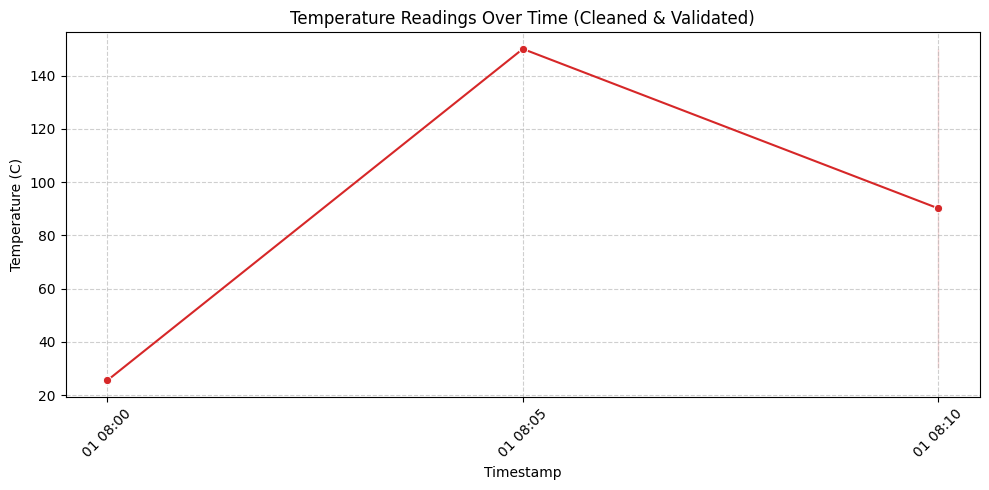

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure data is sorted by timestamp for a correct time-series plot
plot_df = df_final.sort_values('timestamp')

plt.figure(figsize=(10, 5))
sns.lineplot(data=plot_df, x='timestamp', y='temperature', marker='o', color='tab:red')

plt.title('Temperature Readings Over Time (Cleaned & Validated)')
plt.xlabel('Timestamp')
plt.ylabel('Temperature (C)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate and display descriptive statistics
stats_summary = df_final.describe(include='all')
display(stats_summary)

,timestamp,machine_id,temperature,vibration,pieces_produced,defects_found
count,4,4,4.000000,4.000,4.000000,0.0
unique,NaN,3,NaN,NaN,NaN,NaN
top,NaN,M_01,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,NaN,NaN,NaN
mean,2023-10-01 08:06:15,NaN,88.925000,1.175,108.750000,NaN
min,2023-10-01 08:00:00,NaN,25.500000,0.900,100.000000,NaN
25%,2023-10-01 08:03:45,NaN,29.025000,1.050,103.750000,NaN
50%,2023-10-01 08:07:30,NaN,90.100000,1.150,107.500000,NaN
75%,2023-10-01 08:10:00,NaN,150.000000,1.275,112.500000,NaN
max,2023-10-01 08:10:00,NaN,150.000000,1.500,120.000000,NaN
